In [1]:
# Reviewer: Alexander Volkovich.

from sklearn.datasets import fetch_california_housing

house_data = fetch_california_housing()

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

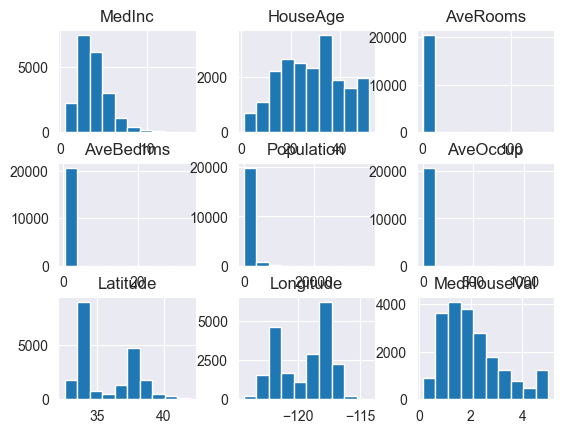

In [2]:
import pandas as pd

df = pd.DataFrame(house_data.data, columns=house_data.feature_names)
df[f'{house_data.target_names[0]}'] = house_data.target
df.hist()

In [3]:
iqr = df.quantile(0.75) - df.quantile(0.25)
outlier_step = 1.5 * iqr
bottom_outliers = df.quantile(0.25) - outlier_step
top_outliers = df.quantile(0.75) + outlier_step
df = df[(df < top_outliers) & (df > bottom_outliers)]

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

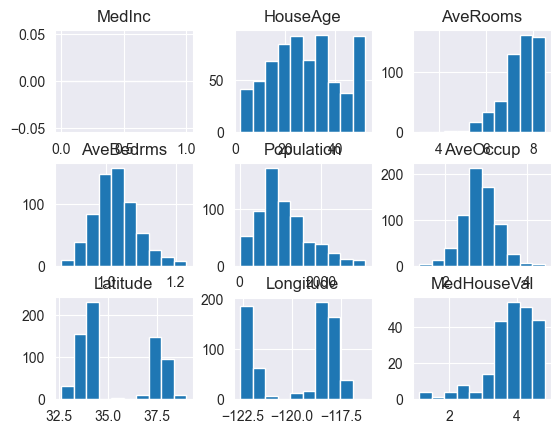

In [4]:
df[df.MedInc.isna()].hist()

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

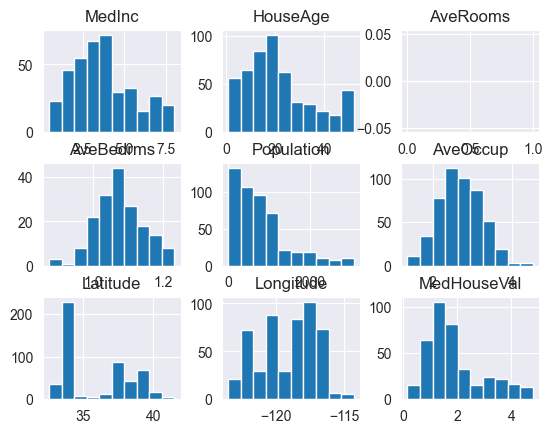

In [5]:
df[df.AveRooms.isna()].hist()

In [7]:
from sklearn.model_selection import train_test_split
df = pd.DataFrame(house_data.data, columns=house_data.feature_names)
df[f'{house_data.target_names[0]}'] = house_data.target
x_train, x_test, y_train, y_test = train_test_split(df.drop('MedHouseVal', axis=1), df['MedHouseVal'], test_size=0.3, random_state=42)
avg_rooms = x_train[x_train.MedInc.isna()].AveRooms.mean()
avg_income = x_train[x_train.AveRooms > avg_rooms].MedInc.mean()
x_train.MedInc.fillna(avg_income)
x_test.MedInc.fillna(avg_income)


20046    1.6812
3024     2.5313
15663    3.4801
20484    5.7376
9814     3.7250
          ...  
17505    2.9545
13512    1.4891
10842    3.5120
16559    3.6500
5786     3.0520
Name: MedInc, Length: 6192, dtype: float64

In [8]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
scores = {}
for i in range(1, round(np.sqrt(len(x_train))) + 1):
    knn = KNeighborsRegressor(i)
    knn.fit(x_train, y_train)
    score_val = knn.score(x_test, y_test)
    scaler = MinMaxScaler()
    scaler.fit(x_train)
    x_train = scaler.transform(x_train)
    x_test = scaler.transform(x_test)
    knn.fit(x_train, y_train)
    scores[i] = cross_val_score(knn, x_train, y_train, cv=5, scoring='r2').mean()
k = max(scores, key=scores.get) + 1

10

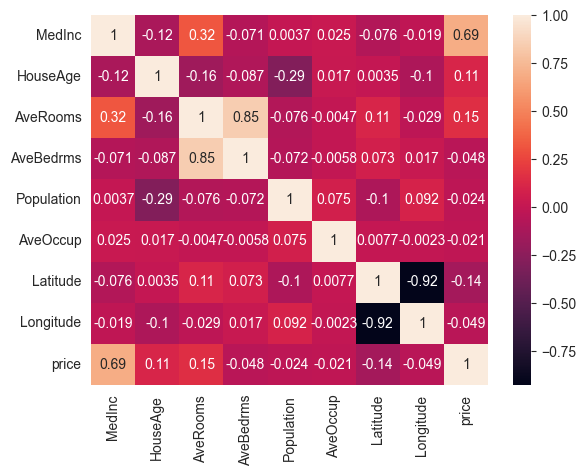

In [159]:
import seaborn as sns
x_train['price'] = y_train
sns.heatmap(x_train.corr(), annot=True)
x_train = x_train.drop('price', axis=1)

In [11]:
knn = KNeighborsRegressor(k)
knn.fit(x_train, y_train)
score_val = knn.score(x_test, y_test)
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
knn.fit(x_train, y_train)
cross_val_score(knn, x_train, y_train, cv=5, scoring='r2').mean()
knn.score(x_test, y_test)

0.7022687992254846